# ChEMBL Data Exploratory Analysis

This notebook explores the ChEMBL IC50 activity data to understand:
- Data distribution and quality
- pIC50 value ranges
- Target organism breakdown
- Molecular structure properties

In [38]:
import sys
sys.path.insert(0, '..')

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 1. Load Data from ChEMBL Database

In [39]:
from libs.data_processing import load_and_process_chembl

# Load sample data (adjust limit for full analysis)
df = load_and_process_chembl(
    db_path='../chembl_36.db',
    limit=50000,  # Set to None for full dataset
    organism_filter=None  # Set to 'Homo sapiens' for human targets only
)

print(f"Dataset shape: {df.shape}")

Loading data from ../chembl_36.db...
Loaded 50,000 records
Processing data...
Cleaned: 50,000 -> 24,192 records (48.4% retained)
Dataset shape: (24192, 15)


## 2. Basic Statistics

In [40]:
# Schema and column types
print("Schema:")
for col, dtype in df.schema.items():
    print(f"  {col}: {dtype}")

Schema:
  activity_id: Int64
  molregno: Int64
  canonical_smiles: String
  standard_value: Float64
  standard_units: String
  standard_type: String
  standard_relation: String
  pchembl_value: Float64
  target_chembl_id: String
  target_name: String
  target_organism: String
  confidence_score: Int64
  units_imputed: Boolean
  value_molar: Float64
  pIC50: Float64


In [41]:
# Null counts
print("\nNull counts:")
null_counts = df.null_count()
for col in df.columns:
    count = null_counts[col][0]
    if count > 0:
        print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")


Null counts:
  pchembl_value: 3415 (14.1%)
  target_organism: 1175 (4.9%)


In [42]:
# Sample data
df.head(10)

activity_id,molregno,canonical_smiles,standard_value,standard_units,standard_type,standard_relation,pchembl_value,target_chembl_id,target_name,target_organism,confidence_score,units_imputed,value_molar,pIC50
i64,i64,str,f64,str,str,str,f64,str,str,str,i64,bool,f64,f64
203001,273324,"""COc1ccc2cc(S(N)(=O)=O)oc2c1""",15.0,"""nM""","""IC50""","""=""",7.82,"""CHEMBL205""","""Carbonic anhydrase 2""","""Homo sapiens""",8,false,1.5000e-8,7.82
160996,126853,"""Cc1ccc(C(=O)c2cn(CCN3CCOCC3)c3…",2.8,"""nM""","""IC50""","""=""",8.55,"""CHEMBL3571""","""Cannabinoid receptor 1""","""Rattus norvegicus""",8,false,2.8000e-9,8.55
168443,126938,"""O=C(c1ccc2ccccc2c1)c1cn(CCN2CC…",59.0,"""nM""","""IC50""","""=""",7.23,"""CHEMBL3571""","""Cannabinoid receptor 1""","""Rattus norvegicus""",8,false,5.9000e-8,7.23
180799,159476,"""O=C(CCCCCC/C(=N\O)c1ccc2ccccc2…",8.5,"""nM""","""IC50""","""=""",8.07,"""CHEMBL325""","""Histone deacetylase 1""","""Homo sapiens""",8,false,8.5000e-9,8.07
167837,100796,"""CN1CCN=C1c1ccc(C(=O)N2CCN(S(=O…",7.0,"""nM""","""IC50""","""=""",8.15,"""CHEMBL244""","""Coagulation factor X""","""Homo sapiens""",8,false,7.0000e-9,8.15
87170,129020,"""O=C1NC(=O)C2(CCSc3cc(Cl)ccc32)…",1000.0,"""nM""","""IC50""","""=""",6.0,"""CHEMBL3081""","""Aldo-keto reductase family 1 m…","""Bos taurus""",8,false,0.000001,6.0
153068,100736,"""N=C(c1ccc(C(=O)N2CCN(S(=O)(=O)…",24.0,"""nM""","""IC50""","""=""",7.62,"""CHEMBL244""","""Coagulation factor X""","""Homo sapiens""",8,false,2.4000e-8,7.62
161348,259771,"""CN1CCc2cccc3c2[C@@H]1Cc1ccc(Br…",3340.0,"""nM""","""IC50""","""=""",5.48,"""CHEMBL265""","""D(1A) dopamine receptor""","""Rattus norvegicus""",8,false,0.000003,5.48
145760,60800,"""Nc1nc(O)c2[nH]c(N)c(Cc3ccco3)c…",5400.0,"""nM""","""IC50""","""=""",5.27,"""CHEMBL4338""","""Purine nucleoside phosphorylas…","""Homo sapiens""",8,false,0.0000054,5.27


## 3. pIC50 Distribution

In [43]:
# pIC50 statistics
print("pIC50 Statistics:")
print(df.select('pIC50').describe())

pIC50 Statistics:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ pIC50    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 24192.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 6.309788 │
│ std        ┆ 1.568751 │
│ min        ┆ 3.004804 │
│ 25%        ┆ 5.02     │
│ 50%        ┆ 6.23     │
│ 75%        ┆ 7.5      │
│ max        ┆ 12.0     │
└────────────┴──────────┘


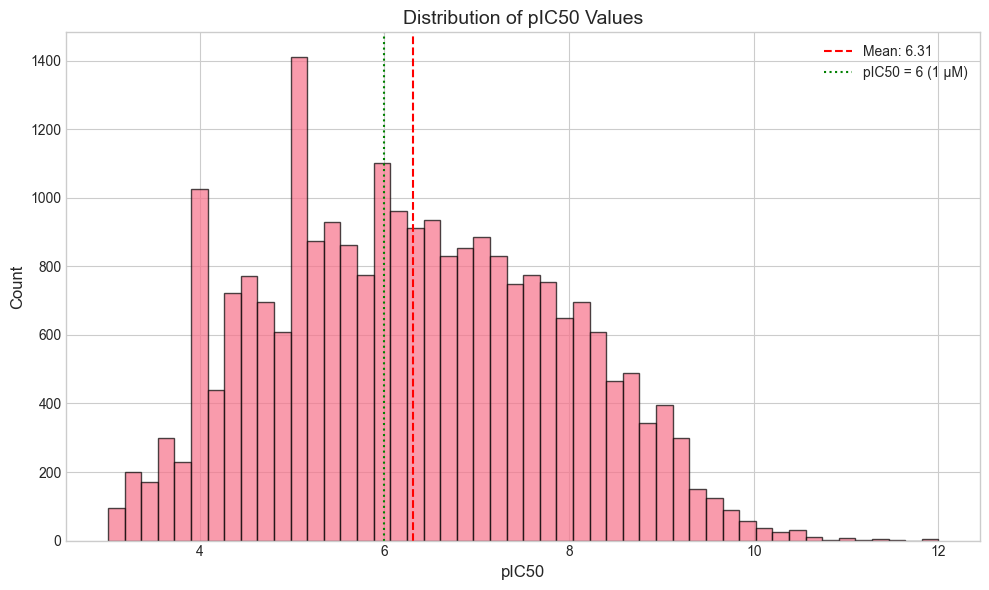

In [44]:
# pIC50 histogram
fig, ax = plt.subplots(figsize=(10, 6))

pIC50_values = df['pIC50'].to_numpy()
ax.hist(pIC50_values, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(pIC50_values.mean(), color='red', linestyle='--', label=f'Mean: {pIC50_values.mean():.2f}')
ax.axvline(6.0, color='green', linestyle=':', label='pIC50 = 6 (1 μM)')

ax.set_xlabel('pIC50', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of pIC50 Values', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 4. Target Organism Analysis

In [45]:
# Top organisms by activity count
organism_counts = df.group_by('target_organism').agg(
    pl.count().alias('count')
).filter(
    pl.col('target_organism').is_not_null()
).sort('count', descending=True)

print("Top 15 target organisms:")
print(organism_counts.head(15))

Top 15 target organisms:
shape: (15, 2)
┌─────────────────────────────────┬───────┐
│ target_organism                 ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Homo sapiens                    ┆ 11212 │
│ Rattus norvegicus               ┆ 4942  │
│ Mus musculus                    ┆ 1606  │
│ Human immunodeficiency virus 1  ┆ 1045  │
│ Cavia porcellus                 ┆ 794   │
│ …                               ┆ …     │
│ Pneumocystis carinii            ┆ 128   │
│ Human rhinovirus sp.            ┆ 101   │
│ Trypanosoma cruzi               ┆ 95    │
│ Cricetulus griseus              ┆ 83    │
│ Influenza A virus (A/Puerto Ri… ┆ 79    │
└─────────────────────────────────┴───────┘


/var/folders/mv/4hvg21415sqbl2x5d_rwtxkc0000gn/T/ipykernel_75386/2343961191.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count')


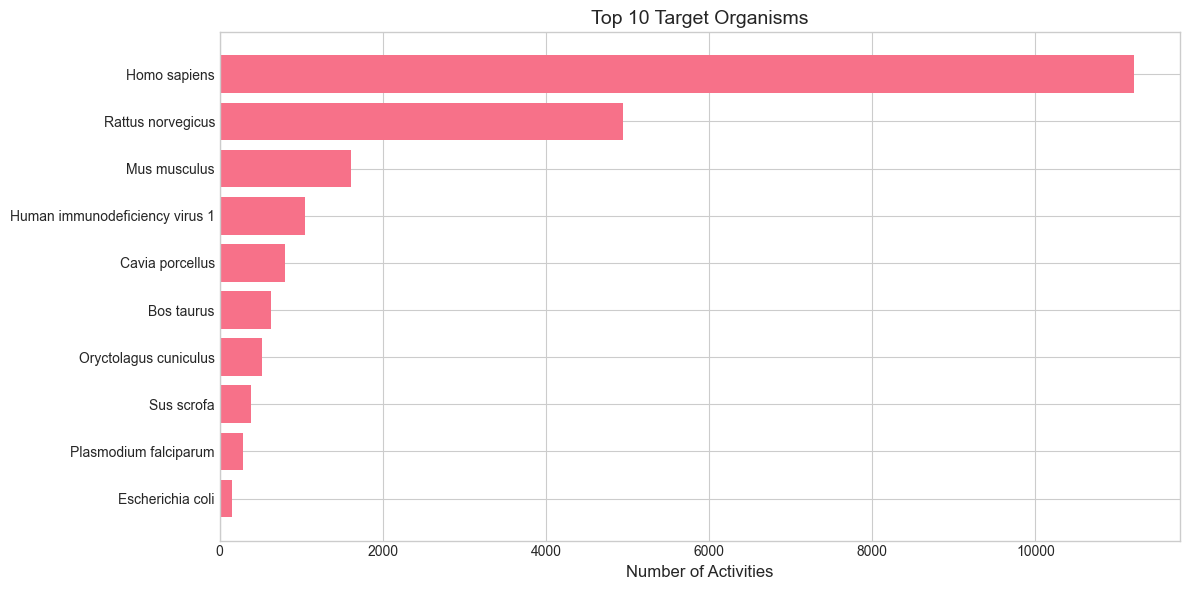

In [46]:
# Bar chart of top organisms
top_organisms = organism_counts.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top_organisms['target_organism'].to_numpy()[::-1], #to_list
    top_organisms['count'].to_numpy()[::-1]
)
ax.set_xlabel('Number of Activities', fontsize=12)
ax.set_title('Top 10 Target Organisms', fontsize=14)

plt.tight_layout()
plt.show()

## 5. Standard Units Analysis

In [47]:
# Unit distribution
unit_counts = df.group_by('standard_units').agg(
    pl.count().alias('count')
).sort('count', descending=True)

print("Unit distribution:")
print(unit_counts)

Unit distribution:
shape: (1, 2)
┌────────────────┬───────┐
│ standard_units ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ nM             ┆ 24192 │
└────────────────┴───────┘


/var/folders/mv/4hvg21415sqbl2x5d_rwtxkc0000gn/T/ipykernel_75386/997852185.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count')


In [48]:
# Imputed units
imputed_count = df.filter(pl.col('units_imputed') == True).shape[0]
print(f"\nRecords with imputed units: {imputed_count} ({imputed_count/len(df)*100:.1f}%)")


Records with imputed units: 24 (0.1%)


## 6. Standard Relation Analysis

The `standard_relation` field indicates:
- `=` : Exact measurement
- `>` : Greater than (censored - compound less active than threshold)
- `<` : Less than (censored - compound more active than threshold)

In [49]:
# Relation distribution
relation_counts = df.group_by('standard_relation').agg(
    pl.count().alias('count'),
    pl.col('pIC50').mean().alias('mean_pIC50')
).sort('count', descending=True)

print("Relation distribution:")
print(relation_counts)

Relation distribution:
shape: (6, 3)
┌───────────────────┬───────┬────────────┐
│ standard_relation ┆ count ┆ mean_pIC50 │
│ ---               ┆ ---   ┆ ---        │
│ str               ┆ u32   ┆ f64        │
╞═══════════════════╪═══════╪════════════╡
│ =                 ┆ 21608 ┆ 6.498834   │
│ >                 ┆ 2412  ┆ 4.58262    │
│ <                 ┆ 136   ┆ 7.353501   │
│ ~                 ┆ 19    ┆ 4.337672   │
│ >=                ┆ 11    ┆ 4.74564    │
│ >>                ┆ 6     ┆ 5.26701    │
└───────────────────┴───────┴────────────┘


/var/folders/mv/4hvg21415sqbl2x5d_rwtxkc0000gn/T/ipykernel_75386/2757574545.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count'),


## 7. Top Targets Analysis

In [50]:
# Top targets by activity count
target_counts = df.group_by(['target_chembl_id', 'target_name']).agg(
    pl.count().alias('count'),
    pl.col('pIC50').mean().alias('mean_pIC50'),
    pl.col('pIC50').std().alias('std_pIC50')
).sort('count', descending=True)

print("Top 15 targets:")
print(target_counts.head(15))

Top 15 targets:
shape: (15, 5)
┌──────────────────┬─────────────────────────────────┬───────┬────────────┬───────────┐
│ target_chembl_id ┆ target_name                     ┆ count ┆ mean_pIC50 ┆ std_pIC50 │
│ ---              ┆ ---                             ┆ ---   ┆ ---        ┆ ---       │
│ str              ┆ str                             ┆ u32   ┆ f64        ┆ f64       │
╞══════════════════╪═════════════════════════════════╪═══════╪════════════╪═══════════╡
│ CHEMBL612545     ┆ Unchecked                       ┆ 768   ┆ 5.763315   ┆ 1.471406  │
│ CHEMBL386        ┆ L1210                           ┆ 519   ┆ 5.458507   ┆ 1.316667  │
│ CHEMBL230        ┆ Prostaglandin G/H synthase 2    ┆ 494   ┆ 6.519561   ┆ 1.338798  │
│ CHEMBL243        ┆ Human immunodeficiency virus t… ┆ 473   ┆ 7.50154    ┆ 1.506421  │
│ CHEMBL372        ┆ Homo sapiens                    ┆ 395   ┆ 6.624394   ┆ 1.863464  │
│ …                ┆ …                               ┆ …     ┆ …          ┆ …         │
│

/var/folders/mv/4hvg21415sqbl2x5d_rwtxkc0000gn/T/ipykernel_75386/3094395264.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count'),


## 8. pIC50 by Organism

In [51]:
# pIC50 statistics by organism (top 5)
top_5_organisms = organism_counts.head(5)['target_organism'].to_list()

pIC50_by_organism = df.filter(
    pl.col('target_organism').is_in(top_5_organisms)
).group_by('target_organism').agg(
    pl.col('pIC50').mean().alias('mean'),
    pl.col('pIC50').std().alias('std'),
    pl.col('pIC50').median().alias('median'),
    pl.count().alias('n')
).sort('n', descending=True)

print("pIC50 by organism:")
print(pIC50_by_organism)

pIC50 by organism:
shape: (5, 5)
┌────────────────────────────────┬──────────┬──────────┬────────┬───────┐
│ target_organism                ┆ mean     ┆ std      ┆ median ┆ n     │
│ ---                            ┆ ---      ┆ ---      ┆ ---    ┆ ---   │
│ str                            ┆ f64      ┆ f64      ┆ f64    ┆ u32   │
╞════════════════════════════════╪══════════╪══════════╪════════╪═══════╡
│ Homo sapiens                   ┆ 6.433178 ┆ 1.561084 ┆ 6.41   ┆ 11212 │
│ Rattus norvegicus              ┆ 6.414308 ┆ 1.474769 ┆ 6.38   ┆ 4942  │
│ Mus musculus                   ┆ 6.069324 ┆ 1.524244 ┆ 6.06   ┆ 1606  │
│ Human immunodeficiency virus 1 ┆ 6.496251 ┆ 1.709252 ┆ 6.48   ┆ 1045  │
│ Cavia porcellus                ┆ 6.743976 ┆ 1.529942 ┆ 6.7    ┆ 794   │
└────────────────────────────────┴──────────┴──────────┴────────┴───────┘


/var/folders/mv/4hvg21415sqbl2x5d_rwtxkc0000gn/T/ipykernel_75386/3656681398.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('n')


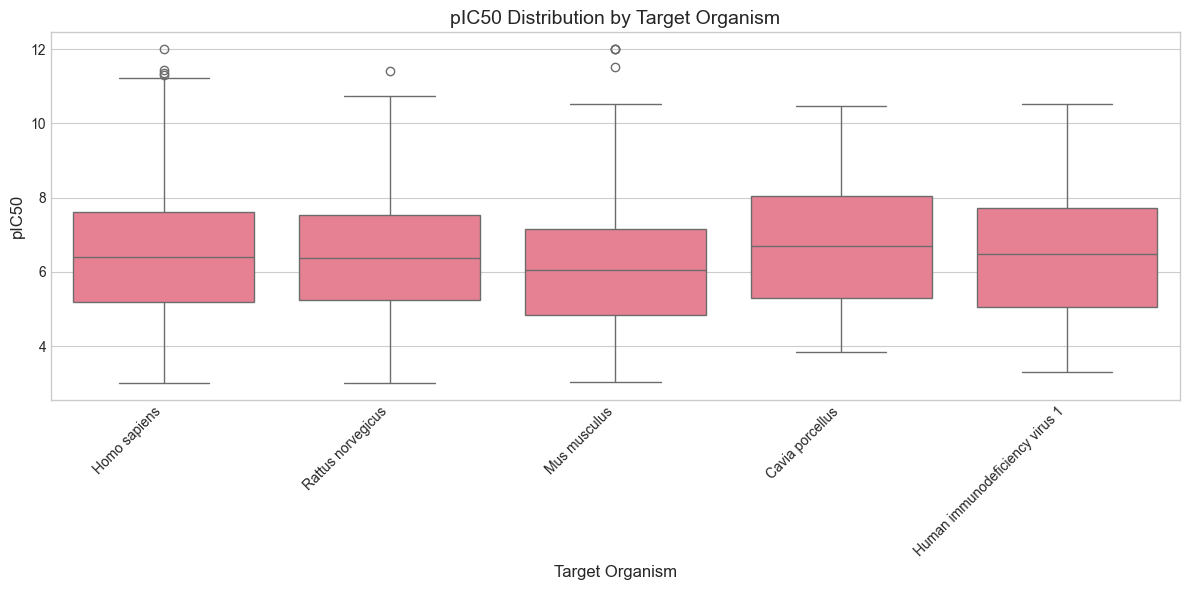

In [52]:
# Box plot of pIC50 by organism
df_top_organisms = df.filter(pl.col('target_organism').is_in(top_5_organisms)).to_pandas()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_top_organisms, x='target_organism', y='pIC50', ax=ax)
ax.set_xlabel('Target Organism', fontsize=12)
ax.set_ylabel('pIC50', fontsize=12)
ax.set_title('pIC50 Distribution by Target Organism', fontsize=14)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 9. Data Quality Summary

In [53]:
print("="*60)
print("DATA QUALITY SUMMARY")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Unique molecules (SMILES): {df['canonical_smiles'].n_unique():,}")
print(f"Unique targets: {df['target_chembl_id'].n_unique():,}")
print(f"Unique organisms: {df['target_organism'].n_unique():,}")
print(f"\npIC50 range: {df['pIC50'].min():.2f} - {df['pIC50'].max():.2f}")
print(f"pIC50 mean ± std: {df['pIC50'].mean():.2f} ± {df['pIC50'].std():.2f}")
print(f"\nImputed units: {imputed_count:,} ({imputed_count/len(df)*100:.1f}%)")
print("="*60)

DATA QUALITY SUMMARY
Total records: 24,192
Unique molecules (SMILES): 24,192
Unique targets: 658
Unique organisms: 69

pIC50 range: 3.00 - 12.00
pIC50 mean ± std: 6.31 ± 1.57

Imputed units: 24 (0.1%)


## 10. Export Processed Data

In [54]:
# Export to Parquet for further analysis
from libs.data_processing import export_to_parquet

# Uncomment to export
# export_to_parquet(df, '../libs/datasets/chembl_eda_export.parquet')